# Практическая работа №3

In [131]:
from tkinter.font import names

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.conftest import pytest_generate_tests
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from statsmodels.graphics.tukeyplot import results
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import numpy as np
import optuna

In [132]:
data = pd.read_csv("data_sets/practice3.csv")

In [133]:
data

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959,3.080,8.381,9.781,3.763,-0.783,-1.257,-1.723,0.650,0.860,0.887,0.958,0.055,unstable
1,9.304,4.903,3.048,1.369,5.068,-1.940,-1.873,-1.255,0.413,0.862,0.562,0.782,-0.006,stable
2,8.972,8.848,3.046,1.215,3.405,-1.207,-1.277,-0.920,0.163,0.767,0.839,0.110,0.003,unstable
3,0.716,7.670,4.487,2.341,3.964,-1.027,-1.939,-0.997,0.446,0.977,0.929,0.363,0.029,unstable
4,3.134,7.609,4.944,9.858,3.526,-1.126,-1.846,-0.554,0.797,0.455,0.657,0.821,0.050,unstable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2.930,9.488,2.377,6.188,3.343,-0.658,-1.449,-1.236,0.602,0.780,0.814,0.608,0.024,unstable
9996,3.392,1.275,2.955,6.895,4.350,-1.664,-0.952,-1.733,0.502,0.567,0.286,0.366,-0.026,stable
9997,2.364,2.842,8.776,1.009,4.300,-1.381,-0.944,-1.975,0.488,0.987,0.149,0.146,-0.032,stable
9998,9.632,3.994,2.757,7.821,2.515,-0.966,-0.650,-0.899,0.365,0.588,0.889,0.818,0.038,unstable


In [134]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


### Статистический анализ

In [135]:
data.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,5.250,5.250,5.250,5.250,3.750,-1.250,-1.250,-1.250,0.525,0.525,0.525,0.525,0.016
std,2.743,2.743,2.743,2.743,0.752,0.433,0.433,0.433,0.274,0.274,0.274,0.274,0.037
min,0.501,0.500,0.501,0.500,1.583,-2.000,-2.000,-2.000,0.050,0.050,0.050,0.050,-0.081
25%,2.875,2.875,2.876,2.875,3.218,-1.625,-1.625,-1.625,0.288,0.288,0.288,0.287,-0.016
50%,5.250,5.250,5.250,5.250,3.751,-1.250,-1.250,-1.250,0.525,0.525,0.525,0.525,0.017
75%,7.625,7.625,7.625,7.625,4.282,-0.875,-0.875,-0.875,0.762,0.762,0.762,0.762,0.045
max,9.999,10.000,9.999,9.999,5.864,-0.500,-0.500,-0.500,1.000,1.000,1.000,1.000,0.109


<Figure size 640x480 with 0 Axes>

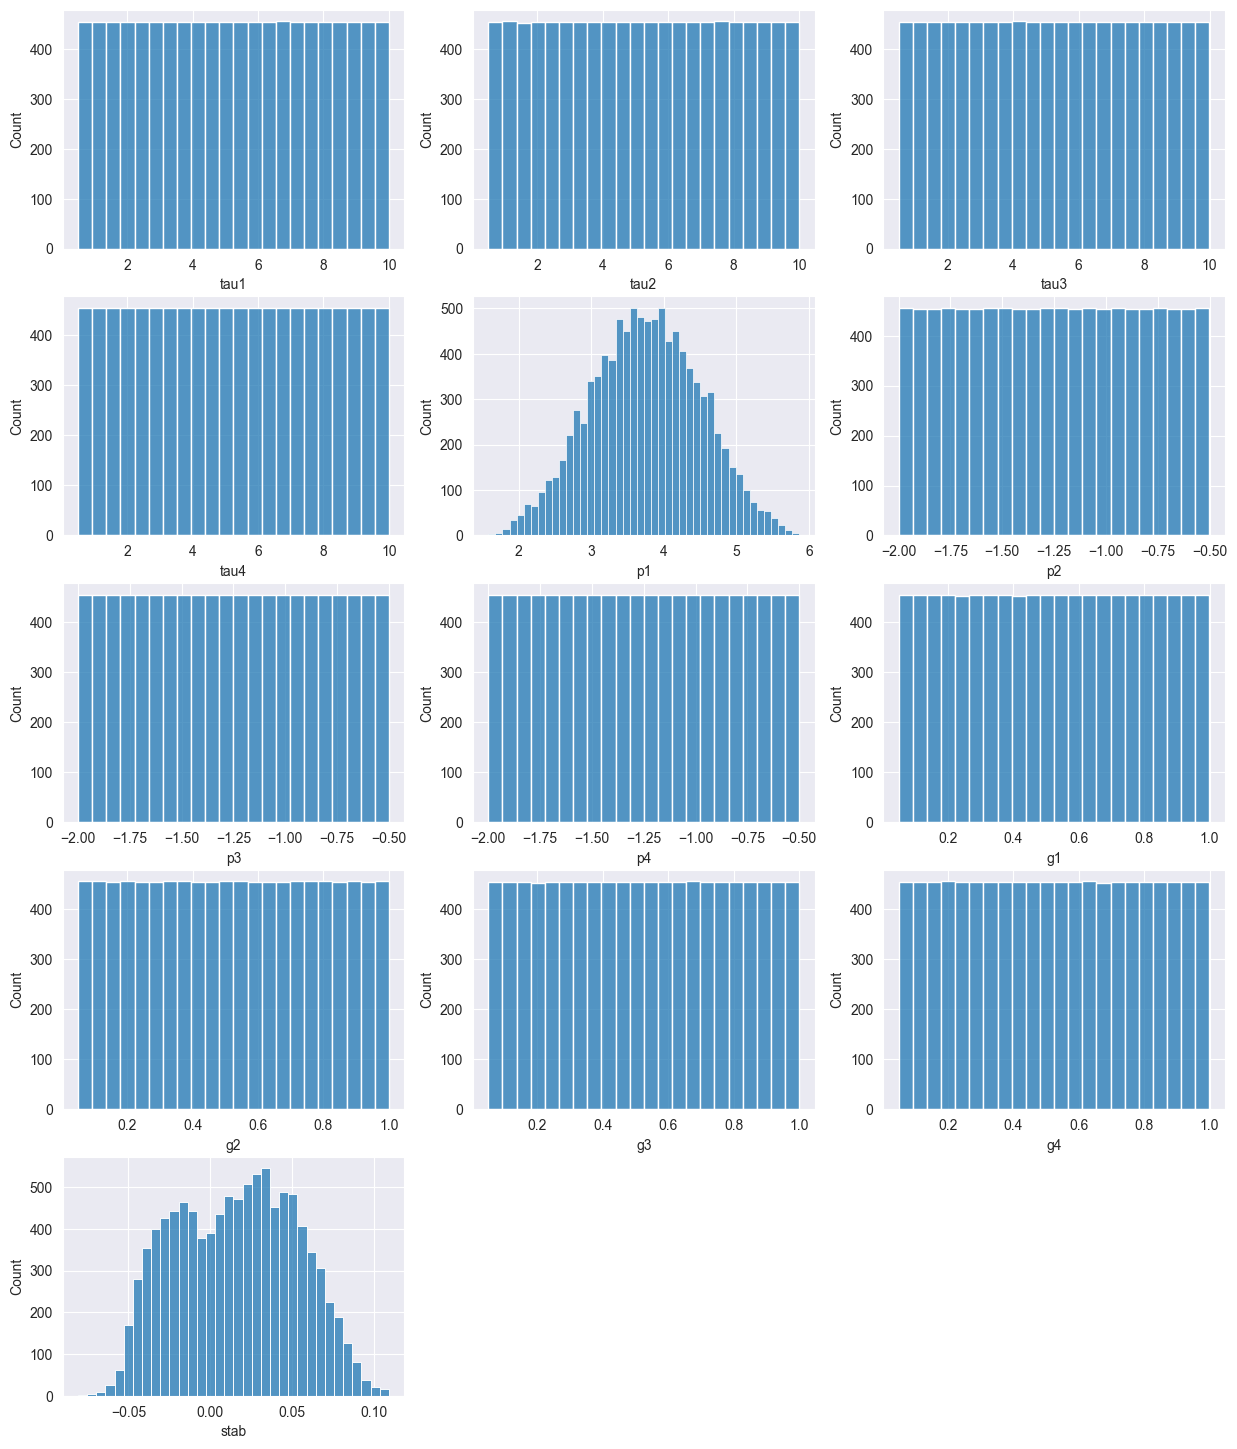

In [136]:
numeric_columns = data.select_dtypes(include=['number']).columns
plt.subplots_adjust(wspace=0.9, hspace=0.9)
fig, ax = plt.subplots(5, 3, figsize=(15, 18))
axes = ax.flatten()
for ax, column in zip(axes, numeric_columns):
    sns.histplot(data=data[column], ax=ax)


axes[-1].set_visible(False)
axes[-2].set_visible(False)

<Axes: >

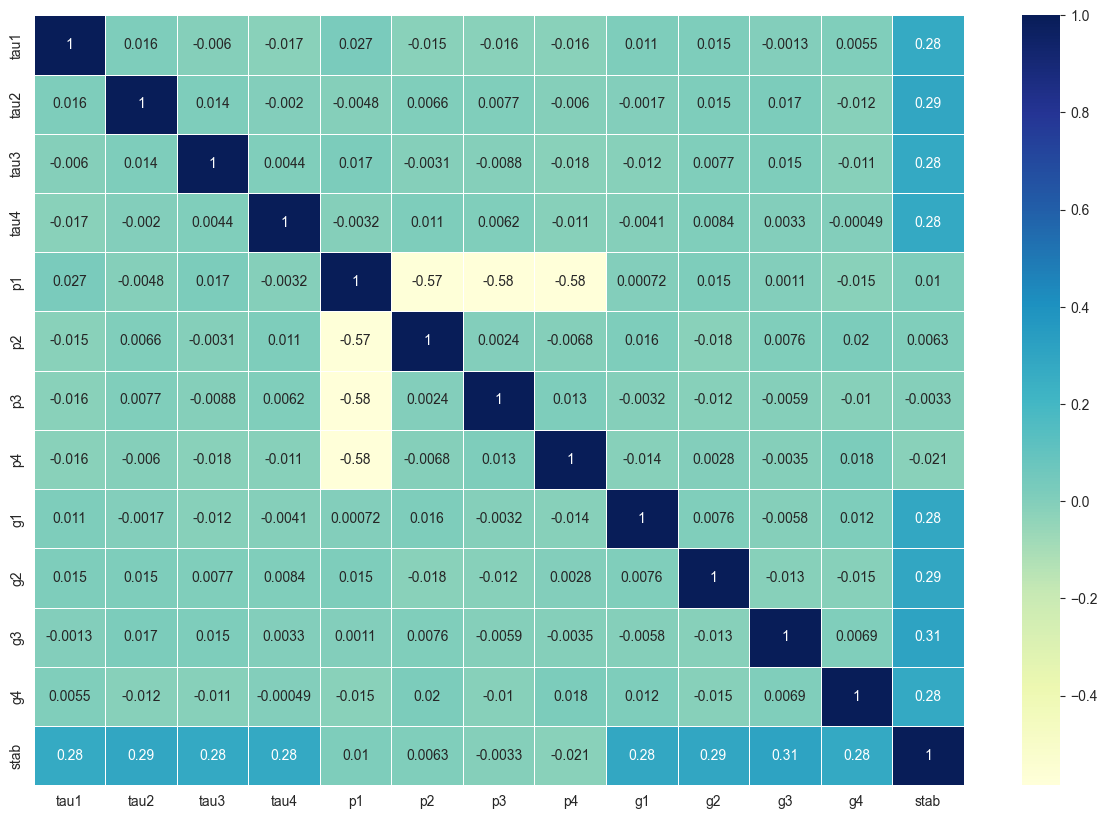

In [137]:
plt.figure(figsize=(15, 10))
sns.heatmap(data.corr(numeric_only = True), annot=True, cmap="YlGnBu", linewidths=.5 )

### Анализ выбросов

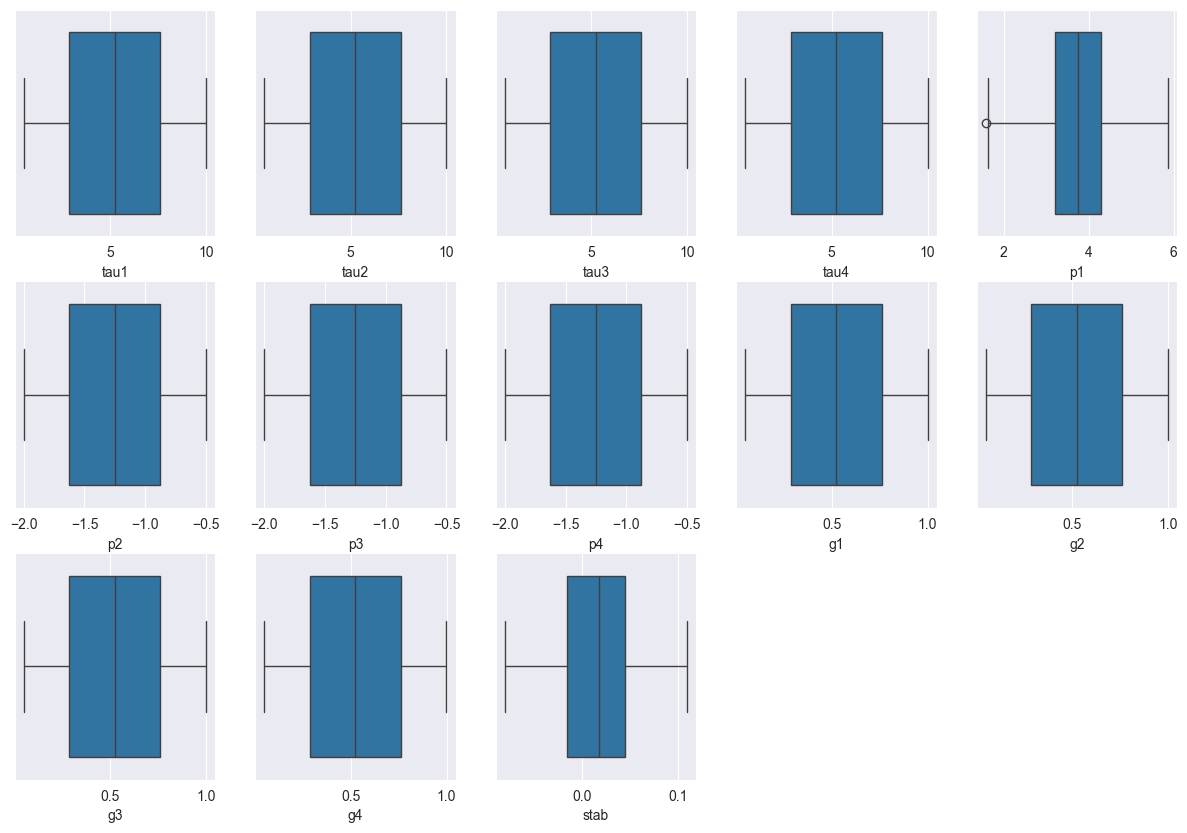

In [138]:
numeric_columns = data.select_dtypes(include=['number']).columns
fig, ax = plt.subplots(3, 5, figsize=(15, 10))
axes = ax.flatten()
for ax, column in zip(axes, numeric_columns):
    sns.boxplot(x = data[column], ax=ax)

axes[-1].set_visible(False)
axes[-2].set_visible(False)

<Axes: ylabel='p1'>

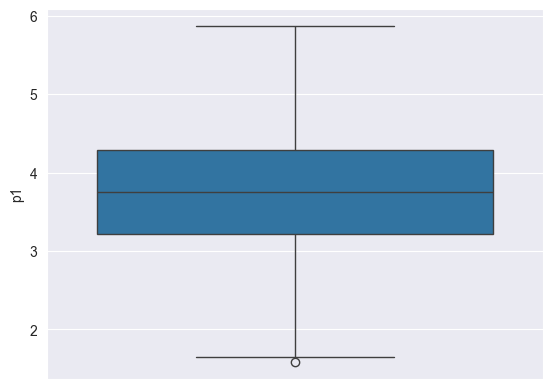

In [139]:
sns.boxplot(data["p1"])

In [140]:
iqr = data["p1"].quantile(0.75) - data["p1"].quantile(0.25)

data[data["p1"] <= 1.5 * iqr]

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
6273,6.698,7.861,9.333,2.434,1.583,-0.504,-0.572,-0.507,0.642,0.868,0.494,0.411,0.057,unstable


### Кодирование признаков

In [141]:
data["stabf"] = data["stabf"].map({"stable": 1, "unstable": 0})

In [142]:
vif_data = pd.DataFrame()

vif_data["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]

vif_data["Features"] = data.columns

vif_data

C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF,Features
0,4.594,tau1
1,4.560,tau2
2,4.580,tau3
3,4.518,tau4
4,inf,p1
5,inf,p2
6,inf,p3
7,inf,p4
8,4.632,g1
9,4.675,g2


## Обучение модели регрессии

Прежде, чем приступить к обучению моделей, сделаем несколько вспомогательных инструментов для избежания дублирования кода.

Функция `get_metrics` возвращает список из рассчитанных метрических показателей для предсказанных и истинных значений.

In [143]:
def get_metrics(y_test, y_predicted):
    return [
        r2_score(y_test, y_predicted),
        mean_squared_error(y_test, y_predicted),
        root_mean_squared_error(y_test, y_predicted),
        mean_absolute_error(y_test, y_predicted),
        mean_absolute_percentage_error(y_test, y_predicted)
    ]

Функция `input_into_the_tables` будет использоваться для вставки полученных значений метрик в результирующую таблицу со всеми моделями.

In [144]:
def input_metrics_into_the_table(name_of_model,
                          predict_on_train_y, y_train,
                          predict_on_test_y, y_test,
                          train_and_test_comparing):
    sk_learn_test_metrics = get_metrics(y_test, predict_on_test_y)

    sk_learn_train_metrics = get_metrics(y_train, predict_on_train_y)

    train_and_test_comparing.loc[name_of_model] = sk_learn_train_metrics + sk_learn_test_metrics

Функция `train_models_with_reg` обучает модели с L1, L2 и ElasticNet регуляризациями с использованием GridSearch, RandomSearch, Optuna и возвращает полученные модели в словаре.

In [145]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def train_models_with_reg(X_train, y_train, X_test, y_test):

    result={}
    types_of_reg = {"L1": Lasso, "L2": Ridge, "EN": ElasticNet}

    for name, type_of_reg in types_of_reg.items():
        param_grid = {"alpha":np.logspace(-10, 10).tolist()}
        grid_search_model = GridSearchCV(
            param_grid=param_grid,
            estimator=type_of_reg(),
            scoring="neg_mean_squared_error",
            cv=4
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=param_grid,
            estimator=type_of_reg(),
            scoring="neg_mean_squared_error",
            cv=4
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            model = type_of_reg(alpha = trial.suggest_float('alpha', 1e-10, 1e10, log=True))
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            return mse

        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=100, show_progress_bar=False)

        optuna_model = Lasso(study.best_params["alpha"])

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": grid_search_model.best_estimator_,
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": random_search_model.best_estimator_,
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model": optuna_model,
            "best_params": study.best_params["alpha"]
        }

    return result


Ниже происходит создание датафрейма для хранения метрик.

In [146]:
metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([
    ["Train Data", "Test Data"],
    metrics
])

train_and_test_comparing = pd.DataFrame(columns=columns)
pd.options.display.float_format = '{:.3f}'.format
train_and_test_comparing

Empty DataFrame
Columns: [(Train Data, R2), (Train Data, MSE), (Train Data, RMSE), (Train Data, MAE), (Train Data, MAPE), (Test Data, R2), (Test Data, MSE), (Test Data, RMSE), (Test Data, MAE), (Test Data, MAPE)]
Index: []

In [147]:
X = data.drop("stab", axis=1)
y = data["stab"]

X_train, X_test, y_train, y_test = train_test_split(X, y)

Для начала обучим модель множественной регрессии без регуляризации.

### Множественная регрессия без регуляризации

In [148]:
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

simple_model_train_predict = simple_model.predict(X_train)
simple_model_test_predict = simple_model.predict(X_test)

input_metrics_into_the_table(
    "Linear regression without regularization",
    simple_model_train_predict, y_train,
    simple_model_test_predict, y_test,
    train_and_test_comparing
)

In [149]:
train_and_test_comparing.loc["Linear regression without regularization"]

Train Data  R2      0.813
            MSE     0.000
            RMSE    0.016
            MAE     0.013
            MAPE   14.344
Test Data   R2      0.821
            MSE     0.000
            RMSE    0.016
            MAE     0.013
            MAPE    1.519
Name: Linear regression without regularization, dtype: float64

Модель одинаково хорошо показывает себя как на трейн выборке, так и на тестовой выборке. Попробуем применить регуляризацию для модели.

<Axes: ylabel='stab'>

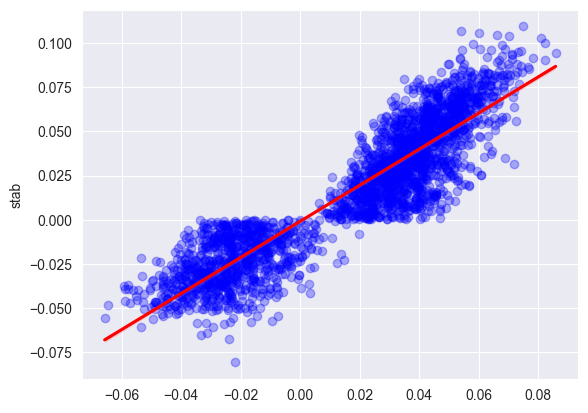

In [150]:
sns.regplot(x = simple_model_test_predict, y=y_test, line_kws={"color": "r"}, scatter_kws={"color": "b", "alpha": 0.3})

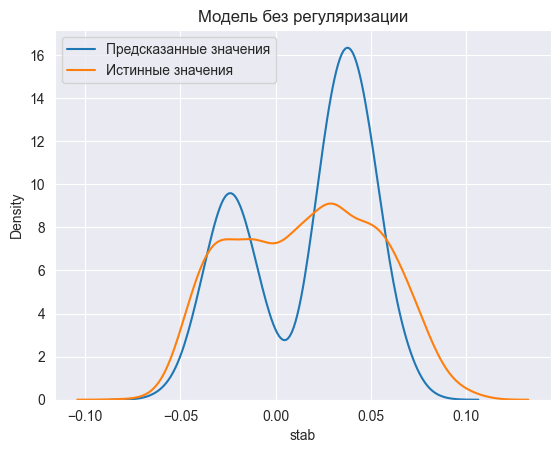

In [151]:
sns.kdeplot(simple_model_test_predict, label="Предсказанные значения")
sns.kdeplot(y_test, label="Истинные значения")

plt.title("Модель без регуляризации")
plt.legend()

### Множественная регрессия с регуляризацией

Для начала с помощью кастомной функции получим модели с видами регуляризаций L1, L2, ElasticNet. В дальнейшем рассмотрим каждый вид регуляризации отдельно.

In [152]:
models_with_regularization = train_models_with_reg(X_train, y_train, X_test, y_test)

#### L1 регуляризация

In [153]:
l1_models = models_with_regularization["L1"]
names = ["GridSearch", "RandomSearch", "Optuna"]

for name, model_dict in zip(names, l1_models.values()):
    print(f"Способ подбора параметров: {name}")
    print(model_dict["best_params"])


Способ подбора параметров: GridSearch
{'alpha': 7.906043210907702e-06}
Способ подбора параметров: RandomSearch
{'alpha': 1.2067926406393288e-06}
Способ подбора параметров: Optuna
3.3539598301338464e-05


Видим, что фреймворк Optuna подобрал наименьший параметр, а GridSearch и RandomSearch подобрали одинаковые параметры. Из-за наличия мультиколлениарности попробуем использовать модель, которая использует параметр, вычисленный GridSearch.

In [154]:
l1_multiple_model = l1_models["GridSearch"]["model"]

l1_multiple_model.coef_

array([ 0.00198517,  0.00205046,  0.00203435,  0.00202709,  0.        ,
       -0.00014965,  0.00055771, -0.        ,  0.02390175,  0.02344873,
        0.02442399,  0.02337739, -0.04041548])

В результате применения Lasso-регуляризации некоторые веса обратились в ноль из-за наличия мультиколлиниарности.

In [155]:
l1_multiple_model_train_predict = l1_multiple_model.predict(X_train)
l1_multiple_model_test_predict = l1_multiple_model.predict(X_test)

input_metrics_into_the_table(
    "Linear regression with Lasso regularization",
    l1_multiple_model_train_predict, y_train,
    l1_multiple_model_test_predict, y_test,
    train_and_test_comparing
)

train_and_test_comparing

Train Data                    \
                                                    R2   MSE  RMSE   MAE   
Linear regression without regularization         0.813 0.000 0.016 0.013   
Linear regression with Lasso regularization      0.813 0.000 0.016 0.013   

                                                   Test Data              \
                                              MAPE        R2   MSE  RMSE   
Linear regression without regularization    14.344     0.821 0.000 0.016   
Linear regression with Lasso regularization 14.394     0.821 0.000 0.016   

                                                         
                                              MAE  MAPE  
Linear regression without regularization    0.013 1.519  
Linear regression with Lasso regularization 0.013 1.520

В результате применения L1-регуляризации показатели метрик практически не изменились.

#### L2 регуляризация

In [156]:
l2_models = models_with_regularization["L2"]
names = ["GridSearch", "RandomSearch", "Optuna"]

for name, model_dict in zip(names, l2_models.values()):
    print(f"Способ подбора параметров: {name}")
    print(model_dict["best_params"])

Способ подбора параметров: GridSearch
{'alpha': 0.6250551925273976}
Способ подбора параметров: RandomSearch
{'alpha': 0.2442053094548655}
Способ подбора параметров: Optuna
1.0389634430920683e-10


RandomSearch показал в качестве результата наибольшее значения коэффициента альфа. Попробуем соответствующую модель.

In [157]:
l2_multiple_model = l2_models["RandomSearch"]["model"]

print(simple_model.coef_, l2_multiple_model.coef_, sep="\n")

[ 1.98732955e-03  2.05271591e-03  2.03712008e-03  2.02942249e-03
 -9.11846627e-05 -2.85683395e-04  5.12121168e-04 -1.35253111e-04
  2.40166853e-02  2.35664163e-02  2.45432517e-02  2.35006774e-02
 -4.03773199e-02]
[ 1.98738490e-03  2.05277554e-03  2.03712687e-03  2.02947470e-03
 -9.11922019e-05 -2.85473162e-04  5.11823594e-04 -1.35158230e-04
  2.40070425e-02  2.35565095e-02  2.45330652e-02  2.34908043e-02
 -4.03762862e-02]


Заметим, что веса модели с L2 регуляризацией немного уменьшились в сравнении с весами модели без регуляризации.

In [158]:
l2_multiple_model_train_predict = l2_multiple_model.predict(X_train)
l2_multiple_model_test_predict = l2_multiple_model.predict(X_test)

input_metrics_into_the_table(
    "Linear regression with Ridge regularization",
    l2_multiple_model_train_predict, y_train,
    l2_multiple_model_test_predict, y_test,
    train_and_test_comparing
)

train_and_test_comparing

Train Data                    \
                                                    R2   MSE  RMSE   MAE   
Linear regression without regularization         0.813 0.000 0.016 0.013   
Linear regression with Lasso regularization      0.813 0.000 0.016 0.013   
Linear regression with Ridge regularization      0.813 0.000 0.016 0.013   

                                                   Test Data              \
                                              MAPE        R2   MSE  RMSE   
Linear regression without regularization    14.344     0.821 0.000 0.016   
Linear regression with Lasso regularization 14.394     0.821 0.000 0.016   
Linear regression with Ridge regularization 14.346     0.821 0.000 0.016   

                                                         
                                              MAE  MAPE  
Linear regression without regularization    0.013 1.519  
Linear regression with Lasso regularization 0.013 1.520  
Linear regression with Ridge regularization 0.013 1.519

Модели с Lasso и Ridge регуляризациями в целом показывают одинаковые результаты. Их отличие лишь в метрике MAPE как для тестовых, так и для обучающих данных - в L2 регуляризации эта метрика уменьшилась. Значит, пока что среди рассмотренных моделей модель с L1 регуляризацией показывает лучший результат.